# Dataset Description

The dataset was provided by **ACWA Power** as part of the Industrial Hackathon.
It contains **9,985 time-series observations** collected from an **Alkaline Water
Electrolyzer (AWE)** stack, recorded at 1-minute intervals.

The data covers **18 sensor features** spanning 5 categories:
- **Electrical**: Current, Voltage, DC Power Consumption
- **Thermal**: H₂/O₂ outlet temperatures, Lye supply temperature, Room temperature
- **Lye & Separator**: Lye concentration, Lye flow, H₂/O₂ separator levels, LDI
- **Gas Purity & Safety**: O₂ content in H₂, H₂ content in O₂, O₂ separator pressure
- **Flow & Water Quality**: H₂ flowrate, DM water conductivity, DM water flow

#Import Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import joblib


# EDA

In [2]:
# ── 1. Load & clean ───────────────────────────────────────────────────────────
df = pd.read_csv("/content/ACWA_DATASET.csv")
df = df.drop_duplicates()
df_clean = df.drop(columns=['Temperature_WTP_production', 'Time'], errors='ignore').copy()
df_clean['is_idle'] = (df_clean['Voltage_1_Stack'] == 0).astype(int)
print(f"Shape: {df_clean.shape}")
df.head()



Shape: (9985, 19)


,Room_temperature,Time,Current_1_stack,Voltage_1_Stack,DC_Power_Consumption_1_Stack,H2_side_outlet_temp_1_stack,O2_side_outlet_temp_1_stack,Lye_Supply_to_Electrolyzer_Temp,Lye_Concentration,Lye_Flow_to_1_Stack,H2_Separator_Level,O2_Separator_Level,LDI_H2_&_O2_Separator,O2_content_in_H2,H2_content_in_O2,Pressure_O2_Separator,H2_Flowrate_Purification_outlet,DM_water_condctivity,Temperature_WTP_production,DM_water_flow_from_B.L.
0,25.75,00:00:00,0.0,0,0.0,25.75,25.75,25.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
1,24.75,00:01:00,0.0,0,0.0,25.25,25.25,25.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
2,24.75,00:02:00,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
3,24.75,00:03:00,0.0,0,0.0,24.75,24.75,24.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
4,24.50,00:04:00,0.0,0,0.0,24.50,24.50,24.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0


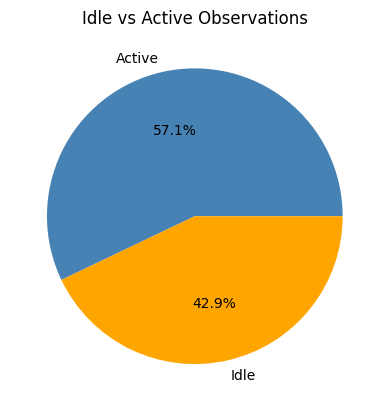

In [3]:
# Ensure this line is executed before any plotting
df["State"] = np.where(df["Voltage_1_Stack"] == 0, "Idle", "Active")
counts = df["State"].value_counts()
plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", colors=["steelblue","orange"])
plt.title("Idle vs Active Observations")
plt.show()


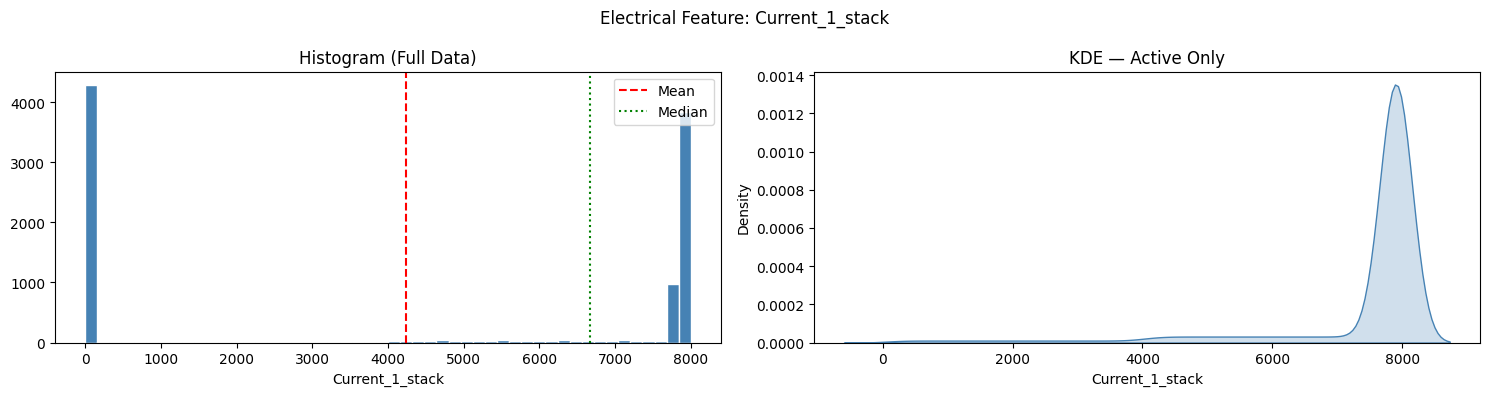

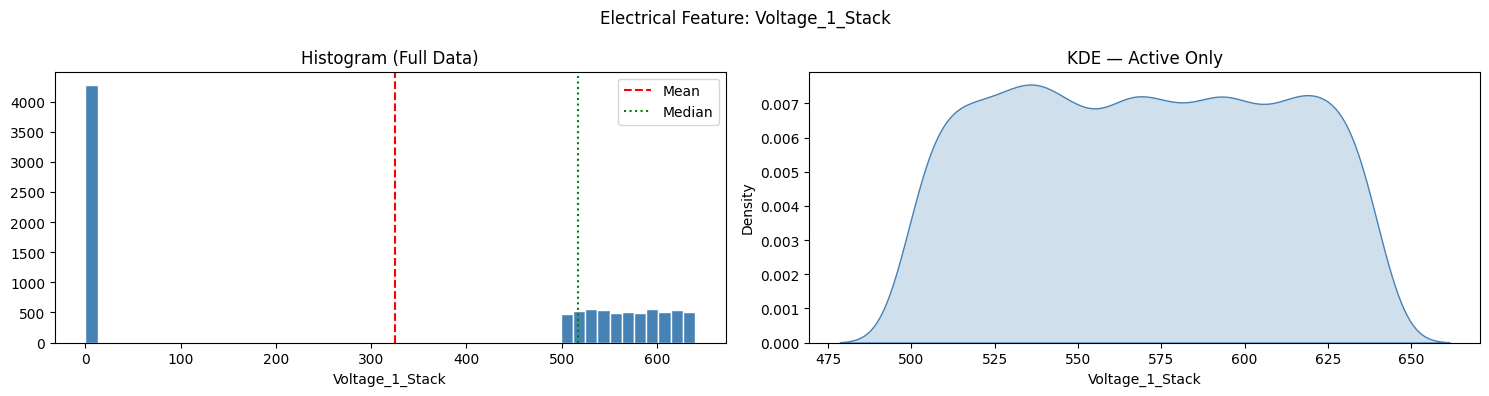

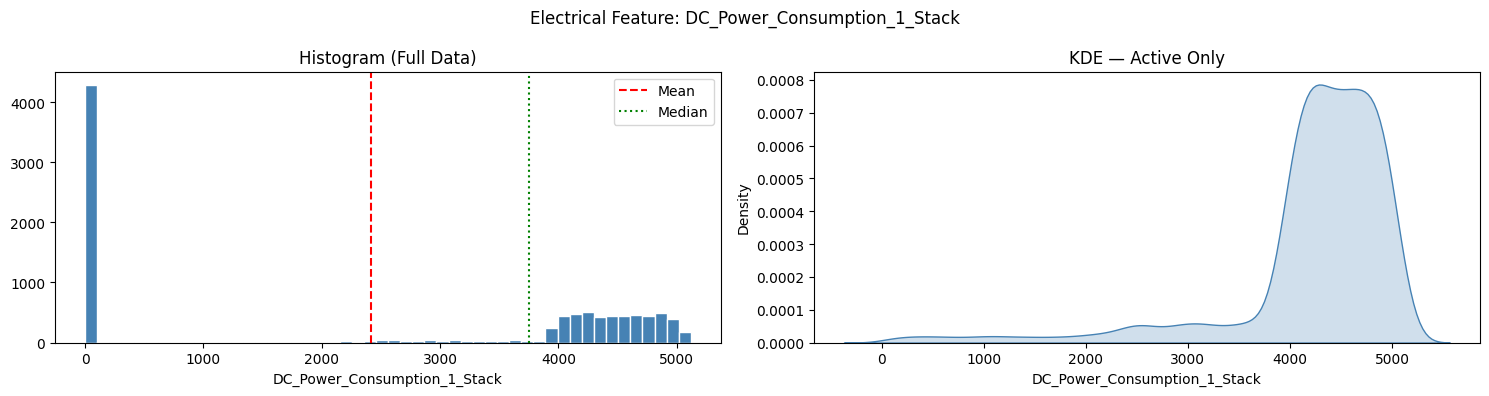

In [4]:
# ELECTRICAL FEATURES
elec_cols = ["Current_1_stack", "Voltage_1_Stack", "DC_Power_Consumption_1_Stack"]

for col in elec_cols:

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Electrical Feature: {col}")

    # Histogram
    axes[0].hist(df[col], bins=50, color="steelblue", edgecolor="white")
    axes[0].axvline(df[col].mean(),   color="red",   linestyle="--", label="Mean")
    axes[0].axvline(df[col].median(), color="green", linestyle=":",  label="Median")
    axes[0].set_title("Histogram (Full Data)")
    axes[0].set_xlabel(col)
    axes[0].legend()

    # KDE — active only
    active = df[df["State"] == "Active"][col]
    sns.kdeplot(active, fill=True, color="steelblue", ax=axes[1])
    axes[1].set_title("KDE — Active Only")
    axes[1].set_xlabel(col)

    # Boxplot Idle vs Active
    #sns.boxplot(data=df, x="State", y=col, hue="State", ax=axes[2], palette={"Idle":"orange","Active":"steelblue"}, legend=False)
    #axes[2].set_title("Idle vs Active")

    plt.tight_layout()
    plt.show()

Electrical Features: The three features are naturally correlated since Power = Current × Voltage.
Current ranges from 0 to 8,001 A, Voltage from 0 to 640 V, and DC Power from 0 to 5,120 kW. The strong spike at zero in all three histograms corresponds to idle periods. During active operation, current clusters tightly around 7,800–8,000 A, suggesting the electrolyzer mostly runs near full load.

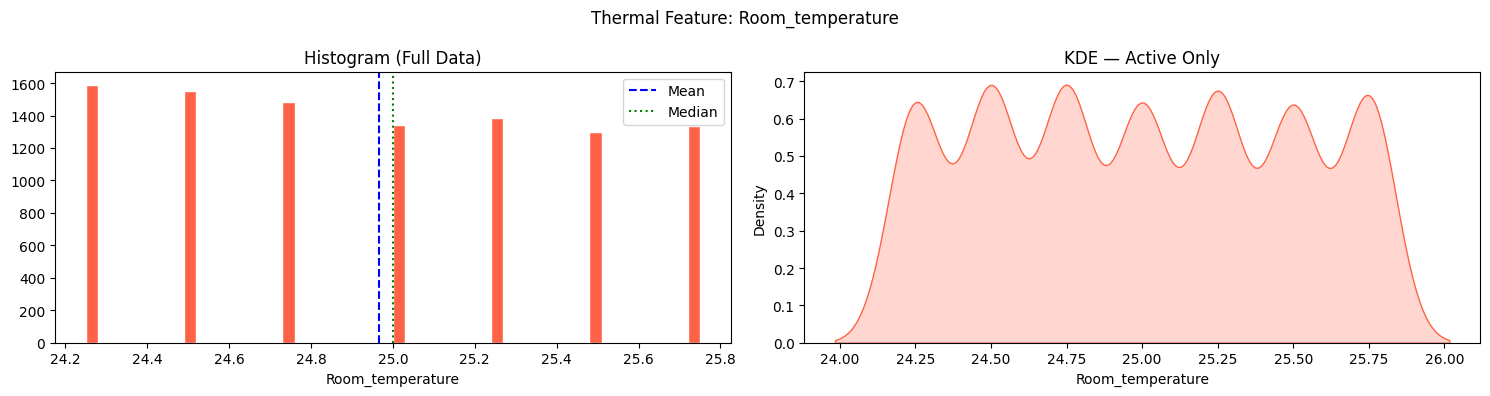

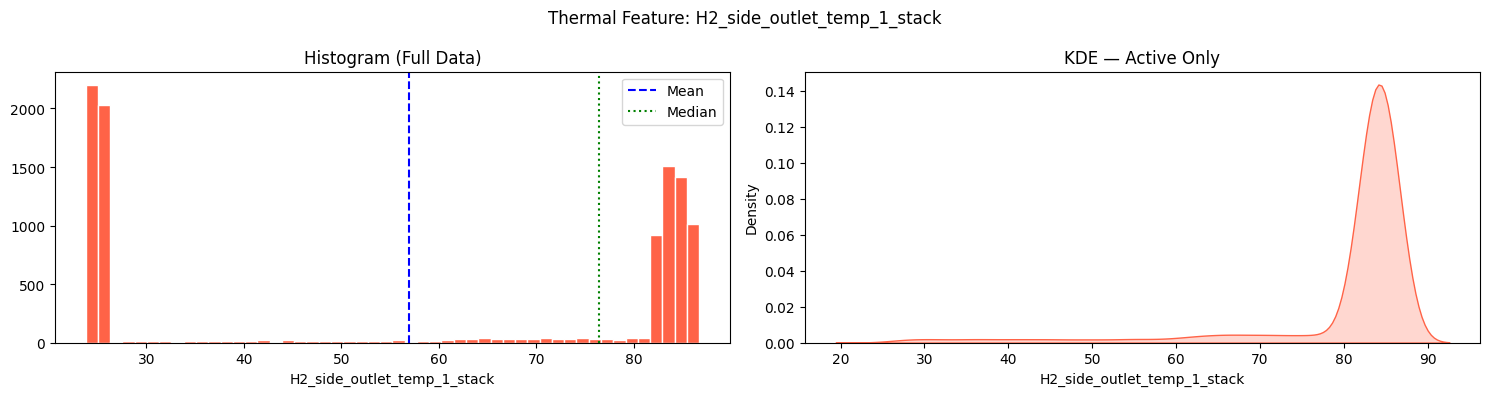

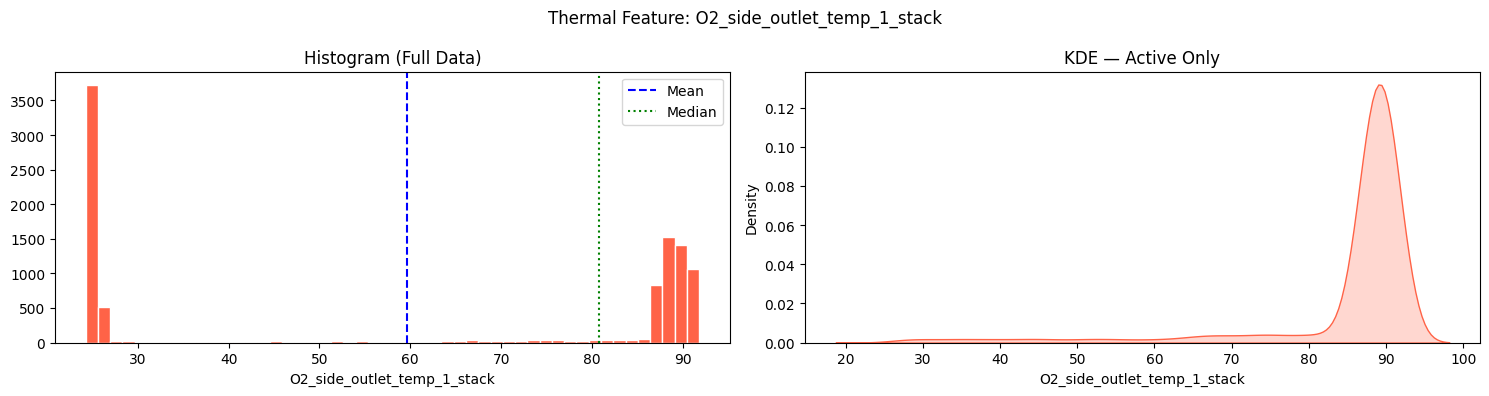

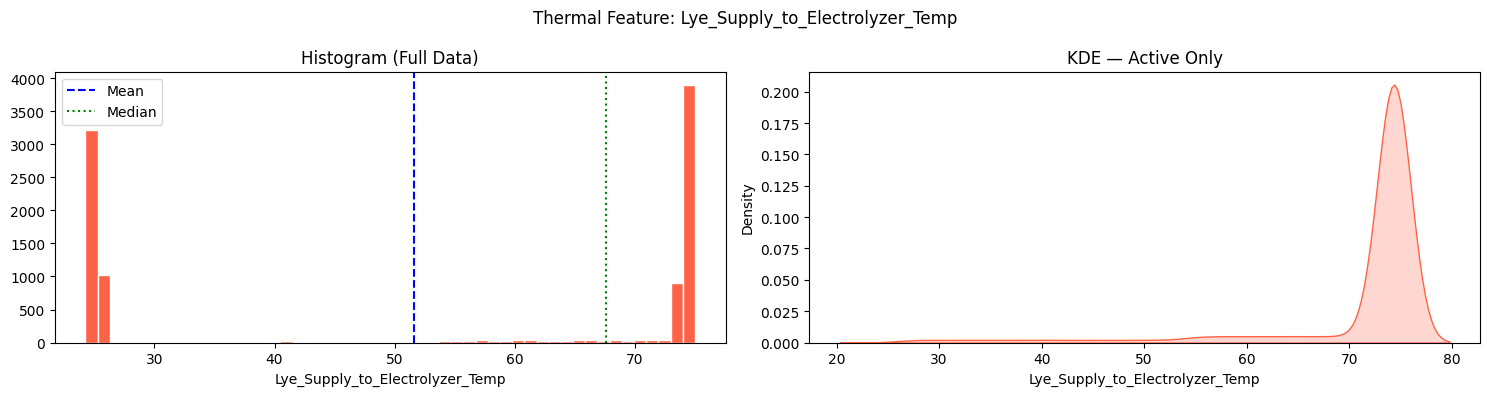

In [5]:
# THERMAL FEATURES


thermal_cols = [
    "Room_temperature",
    "H2_side_outlet_temp_1_stack",
    "O2_side_outlet_temp_1_stack",
    "Lye_Supply_to_Electrolyzer_Temp",
]

for col in thermal_cols:

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Thermal Feature: {col}")

    # Histogram
    axes[0].hist(df[col], bins=50, color="tomato", edgecolor="white")
    axes[0].axvline(df[col].mean(),   color="blue",  linestyle="--", label="Mean")
    axes[0].axvline(df[col].median(), color="green", linestyle=":",  label="Median")
    axes[0].set_title("Histogram (Full Data)")
    axes[0].set_xlabel(col)
    axes[0].legend()

    # KDE — active only
    active = df[df["State"] == "Active"][col]
    sns.kdeplot(active, fill=True, color="tomato", ax=axes[1])
    axes[1].set_title("KDE — Active Only")
    axes[1].set_xlabel(col)


    plt.tight_layout()
    plt.show()

 Thermal Features
Room temperature is very stable (24.25–25.75 °C), indicating a controlled environment. During active operation, H₂ and O₂ outlet temperatures rise to the 80–90 °C range, which is the expected AWE operating target. Lye supply temperature follows a similar trend but lags slightly behind outlet temperatures, which is physically expected since the electrolyte heats up progressively. Idle rows cluster near room temperature for all thermal features.

The distribution of O2 outlet temperatures is bimodal, clearly distinguishing between Idle (~25°C) and Active (~90°C) states. The discrepancy between the mean (60°C) and median (81°C) highlights the non-normal distribution caused by these two distinct modes of operation

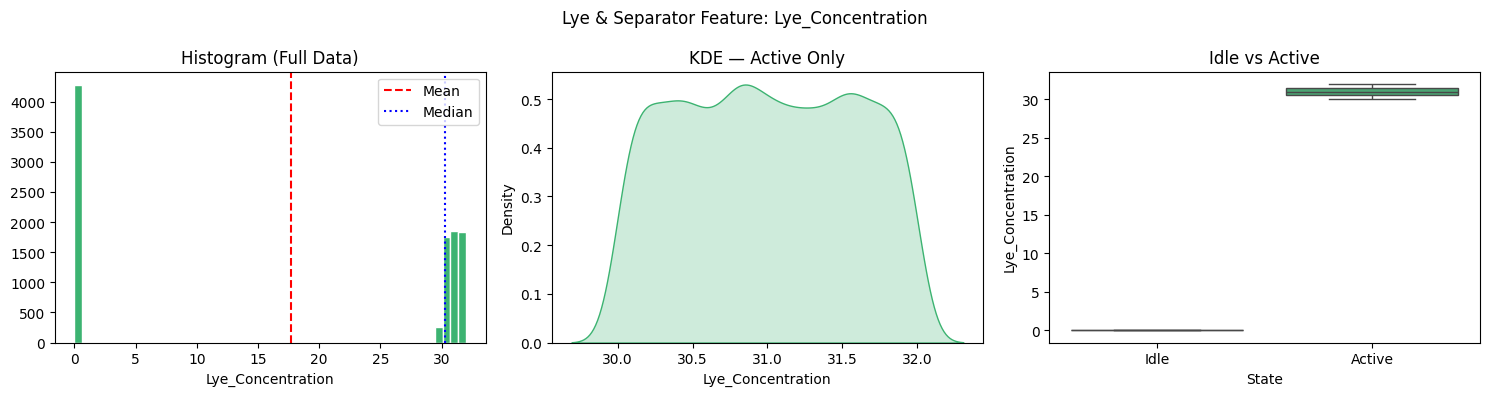

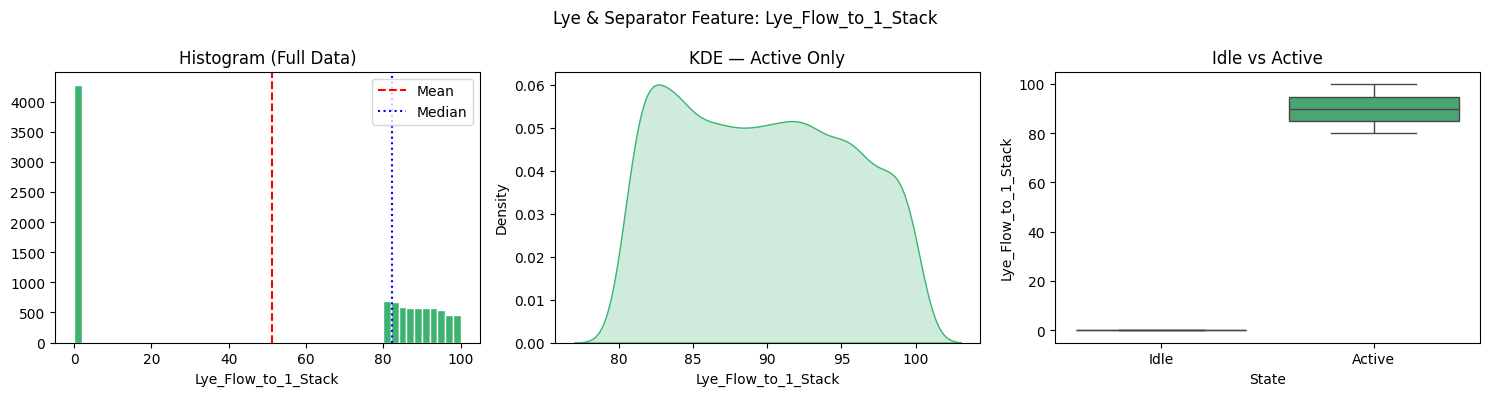

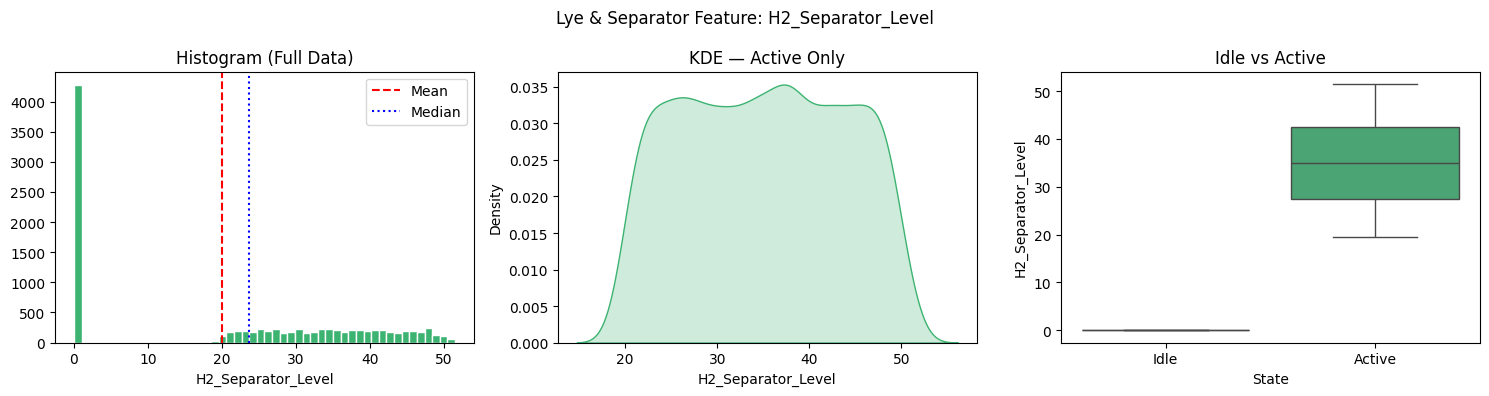

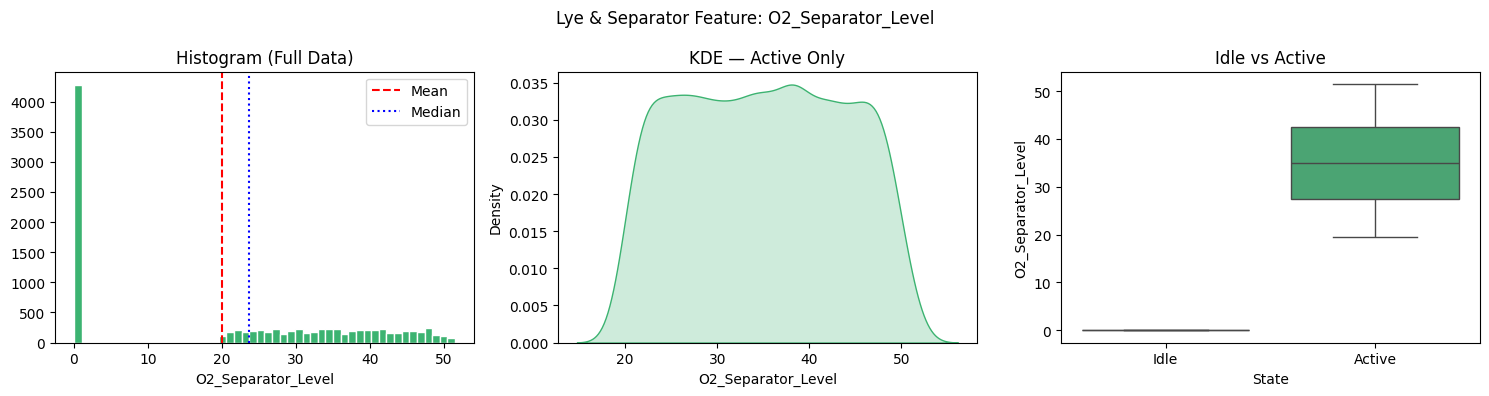

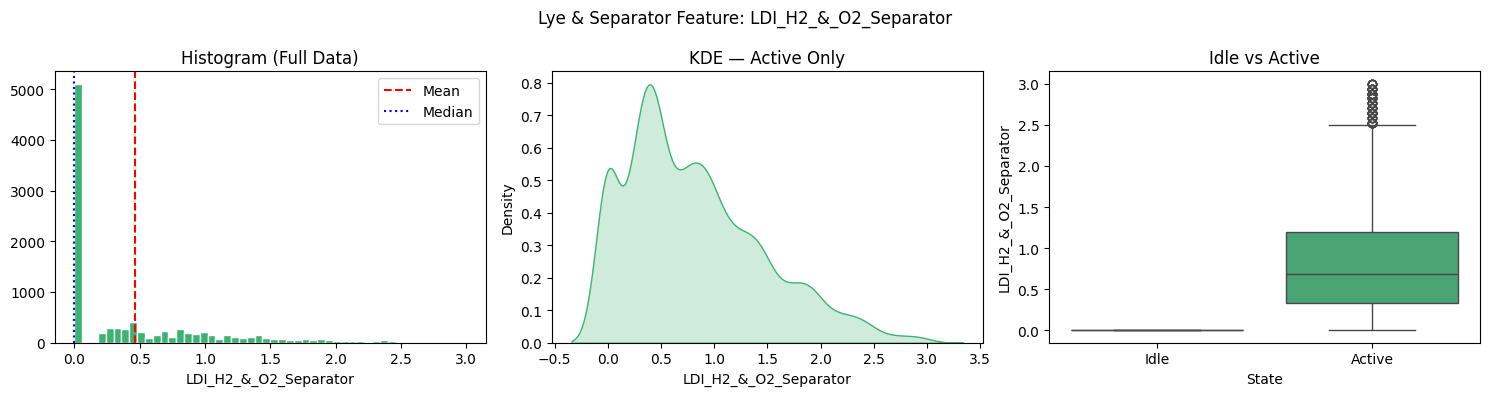

In [6]:
#  LYE & SEPARATOR FEATURES


lye_cols = [
    "Lye_Concentration",
    "Lye_Flow_to_1_Stack",
    "H2_Separator_Level",
    "O2_Separator_Level",
    "LDI_H2_&_O2_Separator",
]

for col in lye_cols:

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Lye & Separator Feature: {col}")

    # Histogram
    axes[0].hist(df[col], bins=50, color="mediumseagreen", edgecolor="white")
    axes[0].axvline(df[col].mean(),   color="red",   linestyle="--", label="Mean")
    axes[0].axvline(df[col].median(), color="blue",  linestyle=":",  label="Median")
    axes[0].set_title("Histogram (Full Data)")
    axes[0].set_xlabel(col)
    axes[0].legend()

    # KDE — active only
    active = df[df["State"] == "Active"][col]
    sns.kdeplot(active, fill=True, color="mediumseagreen", ax=axes[1])
    axes[1].set_title("KDE — Active Only")
    axes[1].set_xlabel(col)

    # Boxplot Idle vs Active
    sns.boxplot(data=df, x="State", y=col, hue="State", ax=axes[2], palette={"Idle":"orange","Active":"mediumseagreen"}, legend=False)
    axes[2].set_title("Idle vs Active")

    plt.tight_layout()
    plt.show()

 Lye & Separator Features
Lye concentration is 0 during idle and stabilizes between 28–32 wt% during active operation, within the normal AWE range of 25–32 wt%. The LDI (liquid level difference between H₂ and O₂ separators) is the most critical safety feature in this section — a small percentage of readings exceed the 1.5 threshold, which indicates a risk of dangerous gas mixing due to diaphragm pressure imbalance. Separator levels for H₂ and O₂ behave almost identically, which is expected in a balanced system.

The original analysis notes a risk threshold of 1.5; observations above this point (like the numerous dots shown) indicate periods of higher operational risk.

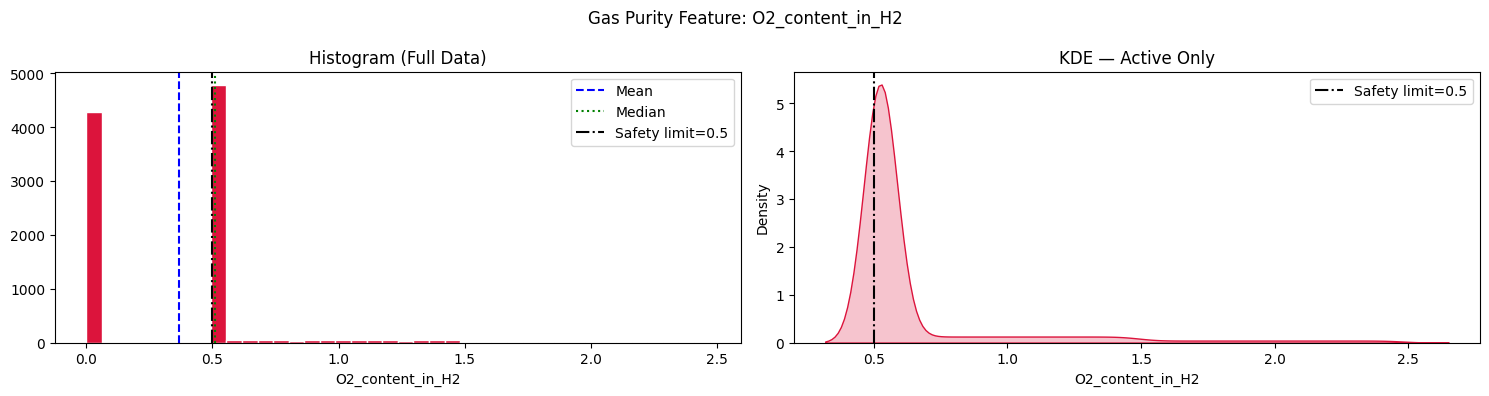

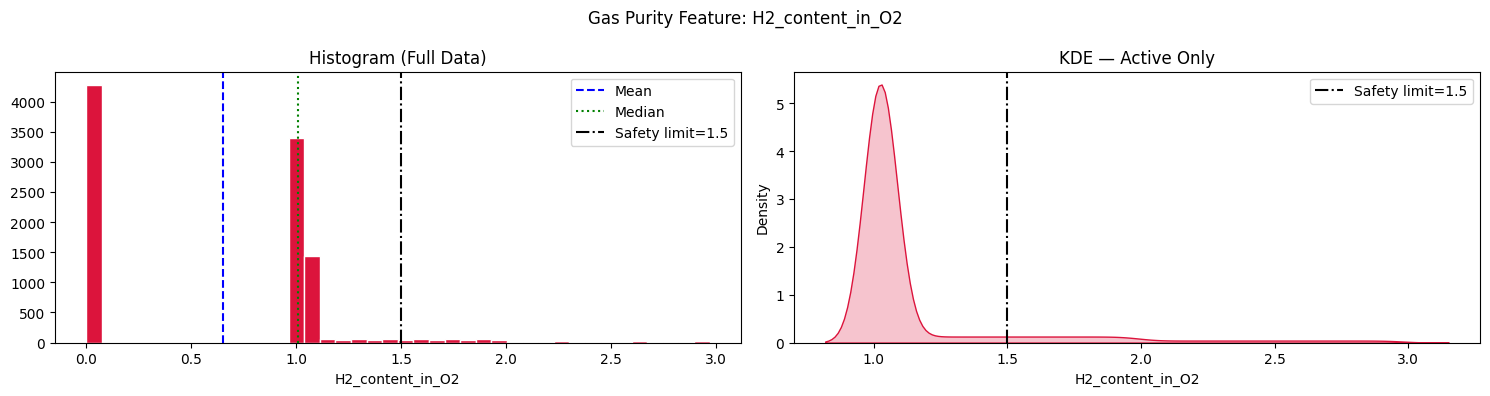

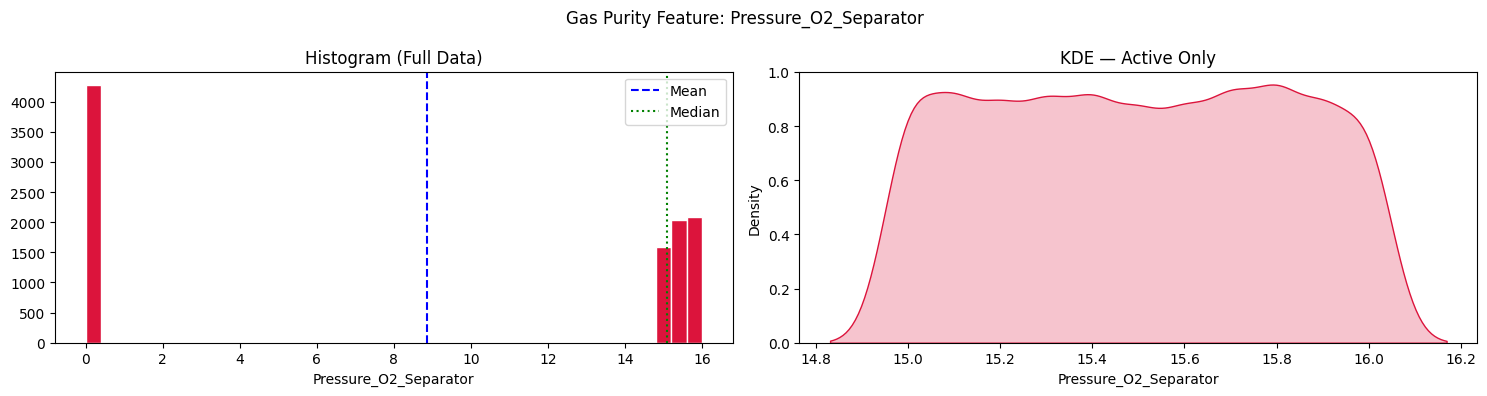

In [7]:
# GAS PURITY & SAFETY FEATURES


gas_cols   = ["O2_content_in_H2", "H2_content_in_O2", "Pressure_O2_Separator"]
# safety limits for first two columns (None = no limit)
limits     = [0.5, 1.5, None]

for col, limit in zip(gas_cols, limits):

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Gas Purity Feature: {col}")

    # Histogram
    axes[0].hist(df[col], bins=40, color="crimson", edgecolor="white")
    axes[0].axvline(df[col].mean(),   color="blue",  linestyle="--", label="Mean")
    axes[0].axvline(df[col].median(), color="green", linestyle=":",  label="Median")
    if limit:
        axes[0].axvline(limit, color="black", linestyle="-.", label=f"Safety limit={limit}")
    axes[0].set_title("Histogram (Full Data)")
    axes[0].set_xlabel(col)
    axes[0].legend()

    # KDE — active only
    active = df[df["State"] == "Active"][col]
    sns.kdeplot(active, fill=True, color="crimson", ax=axes[1])
    if limit:
        axes[1].axvline(limit, color="black", linestyle="-.", label=f"Safety limit={limit}")
        axes[1].legend()
    axes[1].set_title("KDE — Active Only")
    axes[1].set_xlabel(col)



    plt.tight_layout()
    plt.show()                                                                                                    #At Risk (Often exceeds limit)


Gas Purity & Safety Features
O₂ content in H₂ and H₂ content in O₂ are the key safety indicators for crossover risk. A fraction of active readings exceed the standard safety limits (0.5% and 1.5% respectively), flagging potential diaphragm degradation or low-load operation where crossover increases. Pressure in the O₂ separator has very few unique values (discrete readings), clustering around 15–16 bar during normal operation and dropping to 0 during idle — making it a reliable indicator of operating state.

$O_2$ content in $H_2$ : The safety limit is 0.5%. Looking at the KDE — Active Only plot, you can see that the main peak of the data is actually sitting slightly past the 0.5 line. This indicates that while the machine is active, it is frequently operating right at or slightly above the safety threshold.$H_2$ content in $O_2$ : The safety limit is 1.5%. Here, the entire peak is well to the left of the line, meaning this specific metric is staying within a safe range during active operation.

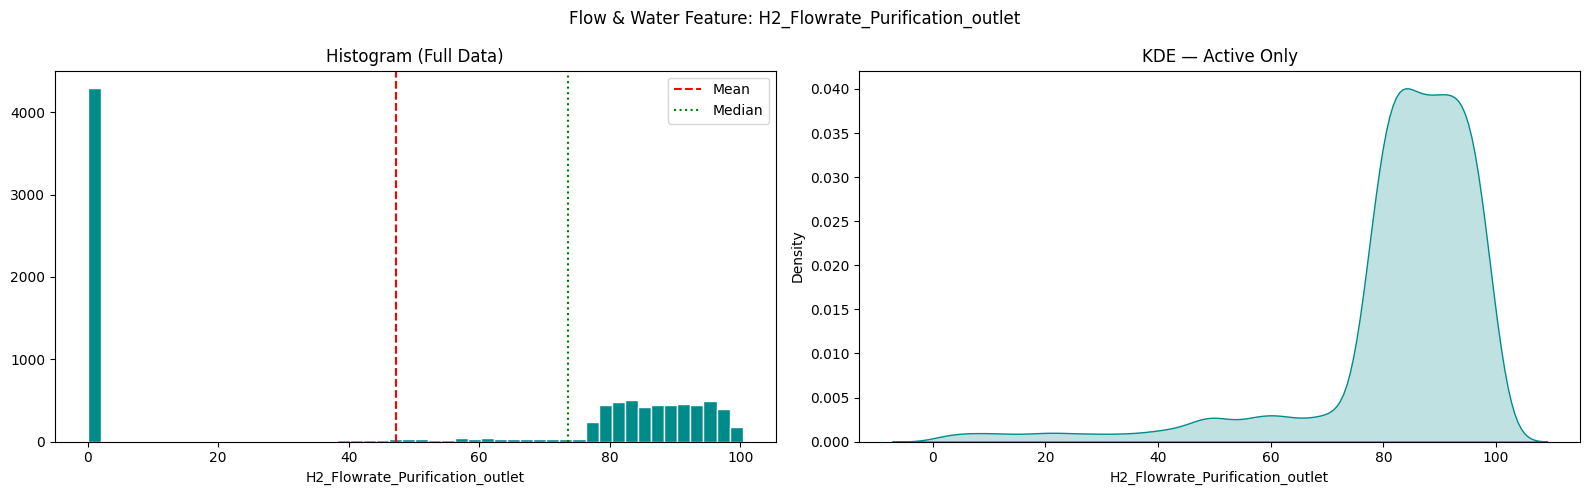

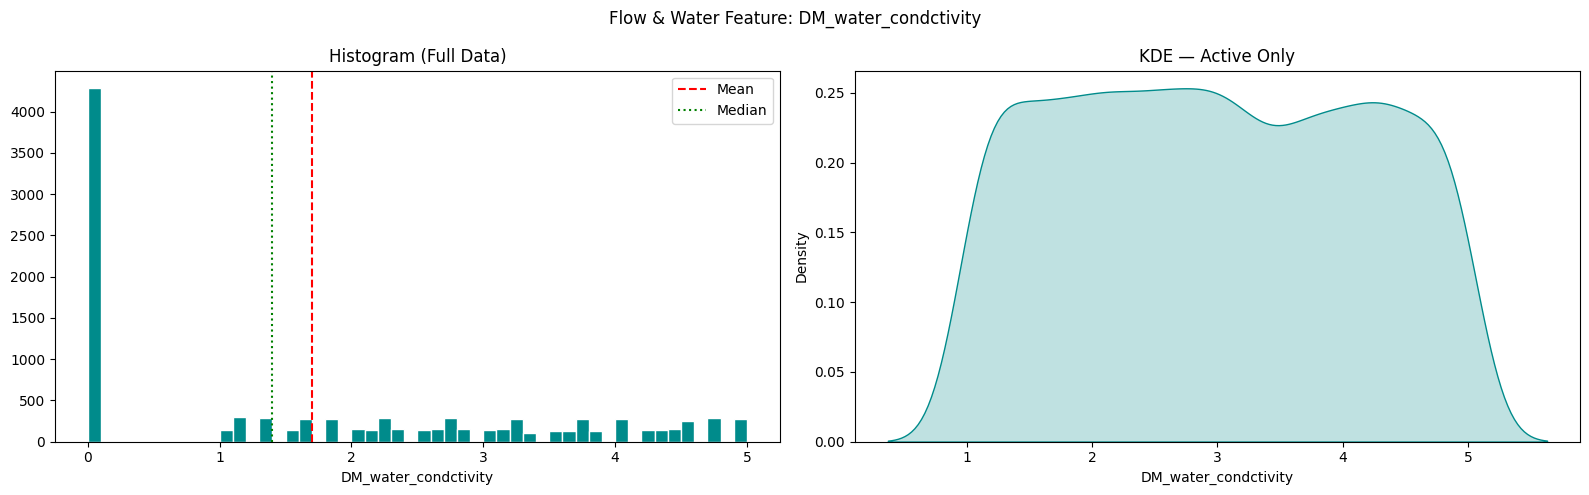

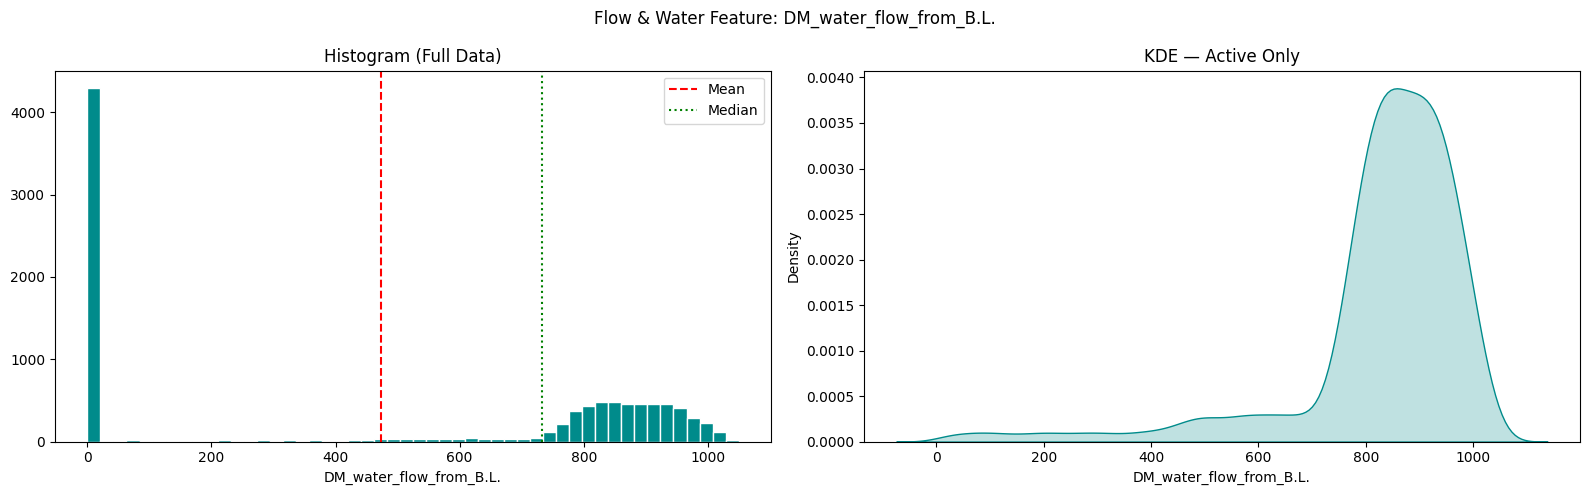

In [8]:
# FLOW & WATER QUALITY FEATURES


water_cols = [
    "H2_Flowrate_Purification_outlet",
    "DM_water_condctivity",
    "DM_water_flow_from_B.L.",
]

for col in water_cols:

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Flow & Water Feature: {col}")

    # Histogram
    axes[0].hist(df[col], bins=50, color="darkcyan", edgecolor="white")
    axes[0].axvline(df[col].mean(),   color="red",   linestyle="--", label="Mean")
    axes[0].axvline(df[col].median(), color="green", linestyle=":",  label="Median")
    axes[0].set_title("Histogram (Full Data)")
    axes[0].set_xlabel(col)
    axes[0].legend()

    # KDE — active only
    active = df[df["State"] == "Active"][col]
    sns.kdeplot(active, fill=True, color="darkcyan", ax=axes[1])
    axes[1].set_title("KDE — Active Only")
    axes[1].set_xlabel(col)



    plt.tight_layout()
    plt.show()

Flow & Water Quality Features
H₂ flowrate and DM water flow both show a clear bimodal split: zero during idle, and high values during active operation. DM water conductivity should ideally stay below 1 µS/cm to avoid contaminating the electrolyte — a portion of readings exceed this threshold, which over time can accelerate electrode degradation and reduce efficiency. This makes conductivity a useful early-warning indicator for water quality issues.

DM water connecttivity indicating that the water quality is frequently outside the ideal specification of $<1.0 \mu$S/cm

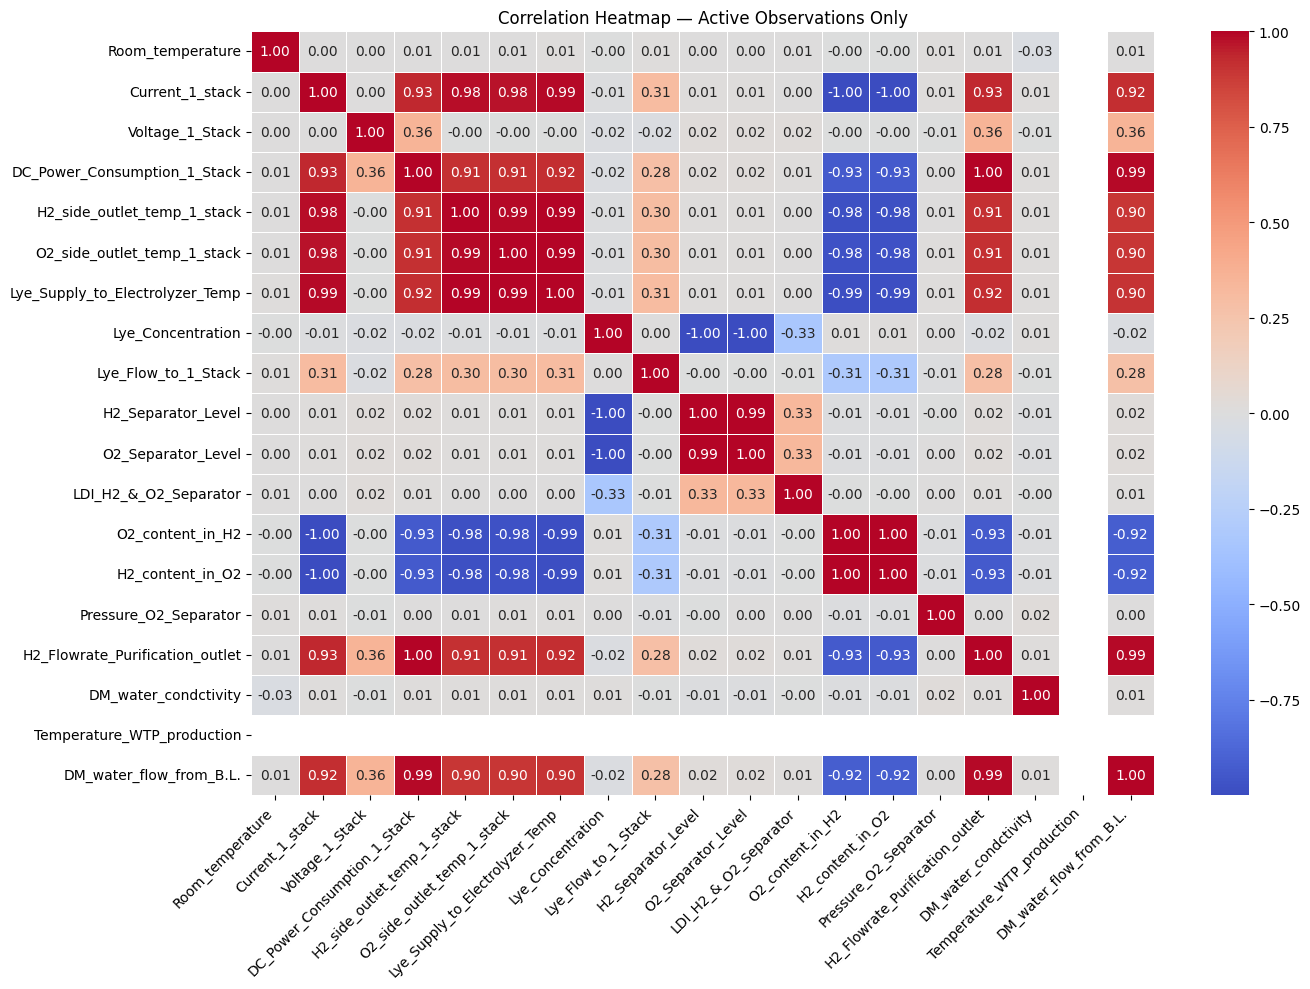

In [9]:
# CORRELATION HEATMAP

num_cols = df.select_dtypes(include="number").columns.tolist()
active_df = df[df["State"] == "Active"][num_cols]

corr = active_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Active Observations Only")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Correlation Heatmap
Current, Voltage, and DC Power are strongly correlated with each other (r ≈ 0.95+), which is expected since they are electrically linked. All three are also strongly correlated with thermal features (H₂ and O₂ outlet temperatures, Lye supply temp), confirming that higher power input directly drives heat generation. H₂ flowrate and DM water flow correlate strongly with electrical features, as more current produces more hydrogen and consumes more water. Gas crossover features (O₂ in H₂, H₂ in O₂) show weaker correlations with electrical features, suggesting crossover is influenced by other factors like diaphragm condition and load dynamics — making them harder to predict and more important to monitor.

In [10]:
active = df[df['Voltage_1_Stack'] > 0]
print(active['DM_water_condctivity'].describe())
print(active['DM_water_condctivity'].quantile([0.75, 0.90, 0.95, 0.99]))

count    5701.000000
mean        2.977741
std         1.185002
min         1.000000
25%         2.000000
50%         2.900000
75%         4.000000
max         5.000000
Name: DM_water_condctivity, dtype: float64
0.75    4.0
0.90    4.6
0.95    4.8
0.99    5.0
Name: DM_water_condctivity, dtype: float64


≤ 2.0  → Normal  (bottom 25% of active readings)

#AI Part:

## Key Thresholds Summary (from PDF + EDA)

| Feature | Threshold
|---|---|
| `O2_content_in_H2` | > 0.5% = warning, > 1.0% = critical
| `H2_content_in_O2` | > 1.5% = warning, > 2.0% = critical
| `LDI_H2_&_O2_Separator` | > 2 = diaphragm pressure risk
| `DM_water_condctivity` | > 2.0 µS/cm = risk
| `Lye_Concentration` | < 25 or > 32 wt% = outside normal AWE range
| `Voltage_1_Stack` | == 0 = Idle (used as state gate, not a risk threshold)

In [11]:
# -------------------------
# thresholds from EDA insights
# -------------------------

# -------------------------
# Labeling function
# -------------------------
def label_maintenance(row):

    # 1. Ignore idle
    if row['Voltage_1_Stack'] == 0:
        return 0

    # 2. Gas purity (critical)
    if row['O2_content_in_H2'] > 1:
        return 1
    if row['H2_content_in_O2'] > 2:
        return 1
    if row['LDI_H2_&_O2_Separator'] > 2:
        return 1

    # 3. Electrolyte issues
    if row['Lye_Concentration'] < 25:
        return 1
    if row['Lye_Concentration'] > 32:
        return 1

    # 4. Water quality
    if row['DM_water_condctivity'] > 1.5:
        return 1

    return 0


# Apply
df_clean['Maintenance_Needed'] = df_clean.apply(label_maintenance, axis=1)

# Save
df_clean.to_csv("ACWA_with_target_FINAL.csv", index=False)

# Check distribution
print(df_clean['Maintenance_Needed'].value_counts())
print(df_clean['Maintenance_Needed'].value_counts(normalize=True))

Maintenance_Needed
0    5003
1    4982
Name: count, dtype: int64
Maintenance_Needed
0    0.501052
1    0.498948
Name: proportion, dtype: float64


##train split

In [12]:
#X = df_clean.drop(columns=['Maintenance_Needed', 'O2_content_in_H2', 'H2_content_in_O2', 'Voltage_1_Stack', 'LDI_H2_&_O2_Separator',
#                     'Lye_Concentration', 'DM_water_condctivity', 'is_idle'])

X = df_clean.drop(columns=['Maintenance_Needed', 'O2_content_in_H2', 'H2_content_in_O2', 'is_idle'])
y = df_clean['Maintenance_Needed']

Accuracy : 0.9334
Precision: 0.9341
Recall   : 0.9334
F1 Score : 0.9334

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      1001
           1       0.92      0.95      0.93       996

    accuracy                           0.93      1997
   macro avg       0.93      0.93      0.93      1997
weighted avg       0.93      0.93      0.93      1997



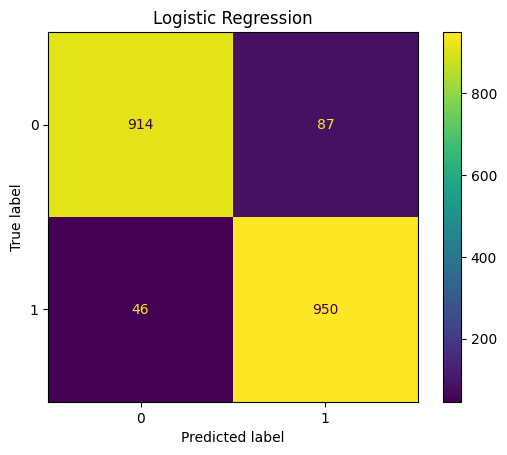

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, recall_score, precision_score
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Logistic Regression")
plt.show()


In [14]:
#save the model
joblib.dump(model, 'maintenance_needed_model.pkl')

['maintenance_needed_model.pkl']